In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

BASE_DIR = Path("dataset")

def load_ecobici_data(base_path=BASE_DIR):
    files = sorted(base_path.glob("[0-9][0-9][0-9][0-9]-*.csv"))
    dfs = []
    for f in files:
        print(f"→ Loading {f.name}…")
        df = pd.read_csv(f, encoding='latin-1')
        dfs.append(df)
    data = pd.concat(dfs, ignore_index=True)
    print(f"Loaded {len(data):,} rows from {len(files)} files.")
    return data

def preprocess(df):
    # Convertir a datetime (dayfirst=True) y eliminar sólo filas con fechas totalmente inválidas
    df['Fecha_Hora_Retiro'] = pd.to_datetime(df['Fecha_Retiro'] + ' ' + df['Hora_Retiro'],
                                             dayfirst=True, errors='coerce')
    df['Fecha_Hora_Arribo'] = pd.to_datetime(df['Fecha_Arribo'] + ' ' + df['Hora_Arribo'],
                                             dayfirst=True, errors='coerce')
    df = df.dropna(subset=['Fecha_Hora_Retiro','Fecha_Hora_Arribo'])

    # Calcular duración en minutos
    df['Duracion_Minutos'] = (df['Fecha_Hora_Arribo'] - df['Fecha_Hora_Retiro']).dt.total_seconds()/60

    # Filtrar trip durations realistas (>=1 min, <=720 min = 12 horas)
    df = df.query("Duracion_Minutos >= 1 & Duracion_Minutos <= 720")

    # Edad razonable: entre 10 y 100 años
    df['Edad_Usuario'] = pd.to_numeric(df['Edad_Usuario'], errors='coerce')
    df = df.query("10 <= Edad_Usuario <= 100")
    df['Edad_Usuario'] = df['Edad_Usuario'].astype(int)

    # Genero codificado: M=0, F=1, Otro=2
    df['Genero_Cod'] = df['Genero_Usuario'].map({'M':0,'F':1}).fillna(2).astype(int)

    # Limpieza de estaciones: rellenar NA con la moda
    for col in ['Ciclo_Estacion_Retiro','Ciclo_EstacionArribo']:
        tmp = pd.to_numeric(df[col], errors='coerce')
        df[col] = tmp.fillna(tmp.mode().iat[0]).astype('Int64')

    # Eliminar duplicados exactos
    df = df.drop_duplicates()

    print(f"After cleaning: {len(df):,} rows remain.")
    return df

if __name__ == "__main__":
    df = load_ecobici_data()
    df_clean = preprocess(df)
    df_clean.to_csv("ecobici.csv", index=False)
    print("Saved → ecobici.csv")




→ Loading 2024-09.csv…
→ Loading 2024-10.csv…
→ Loading 2024-11.csv…
→ Loading 2024-12.csv…
→ Loading 2025-01.csv…
→ Loading 2025-02.csv…
Loaded 11,085,307 rows from 6 files.


C:\Users\Paco\AppData\Local\Temp\ipykernel_10896\518820993.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Edad_Usuario'] = pd.to_numeric(df['Edad_Usuario'], errors='coerce')
C:\Users\Paco\AppData\Local\Temp\ipykernel_10896\518820993.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Edad_Usuario'] = df['Edad_Usuario'].astype(int)
C:\Users\Paco\AppData\Local\Temp\ipykernel_10896\518820993.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try us

After cleaning: 11,082,460 rows remain.
Saved → ecobici.csv


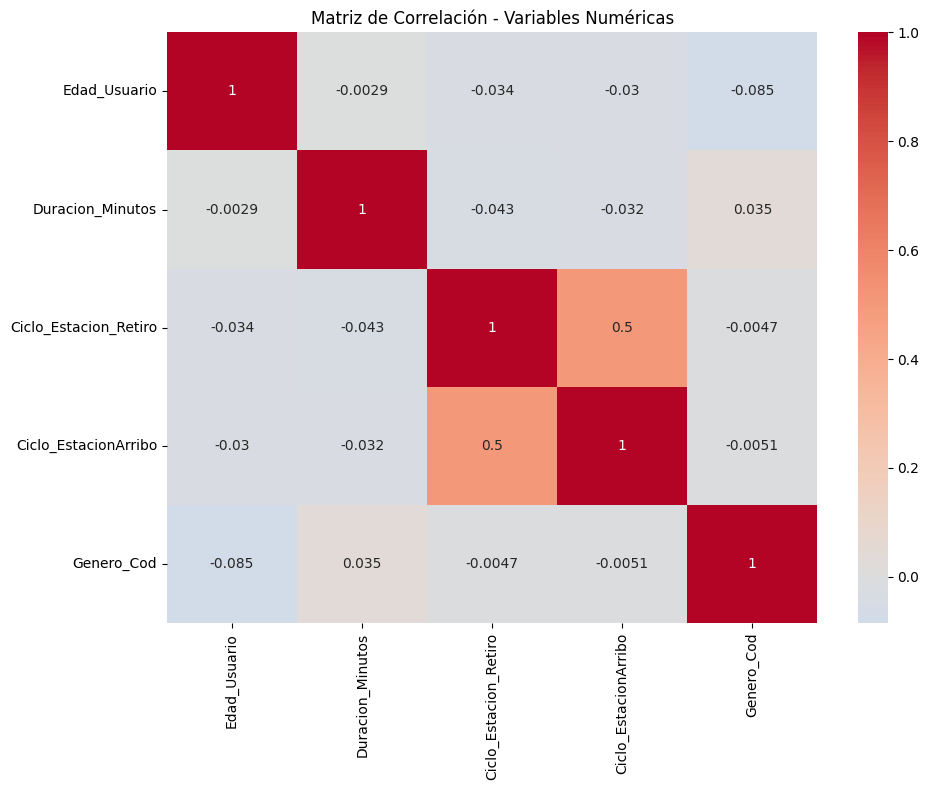

Matriz de Correlación:
                        Edad_Usuario  Duracion_Minutos  Ciclo_Estacion_Retiro  \
Edad_Usuario               1.000000         -0.002890              -0.034125   
Duracion_Minutos          -0.002890          1.000000              -0.042943   
Ciclo_Estacion_Retiro     -0.034125         -0.042943               1.000000   
Ciclo_EstacionArribo      -0.029754         -0.032415               0.503196   
Genero_Cod                -0.084837          0.034521              -0.004691   

                       Ciclo_EstacionArribo  Genero_Cod  
Edad_Usuario                      -0.029754   -0.084837  
Duracion_Minutos                  -0.032415    0.034521  
Ciclo_Estacion_Retiro              0.503196   -0.004691  
Ciclo_EstacionArribo               1.000000   -0.005142  
Genero_Cod                        -0.005142    1.000000  


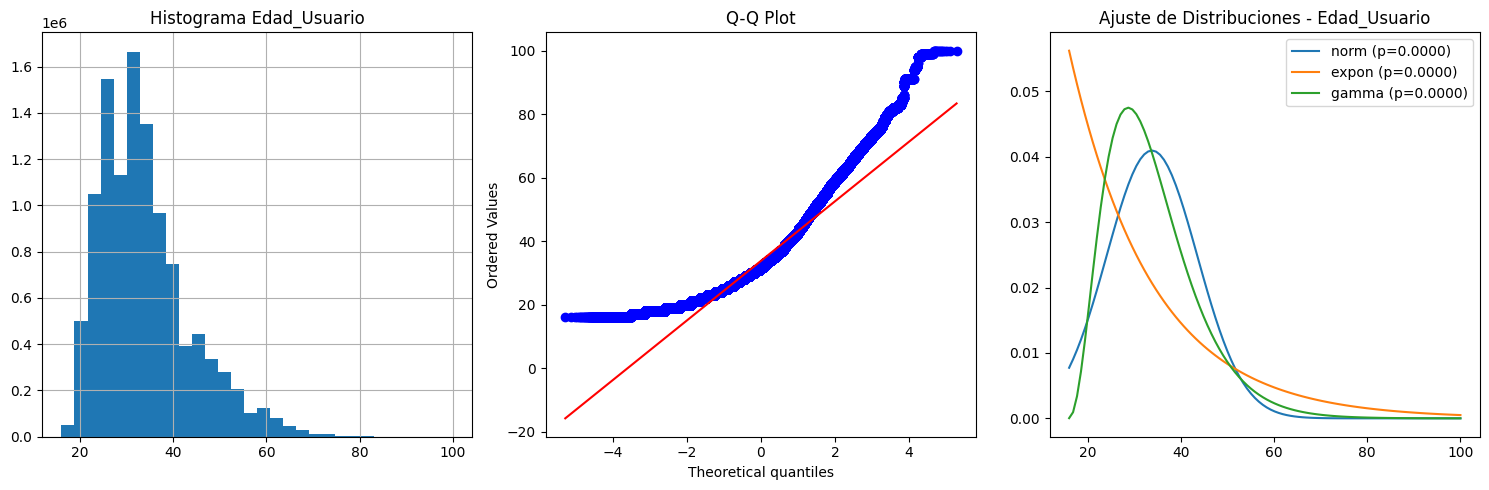

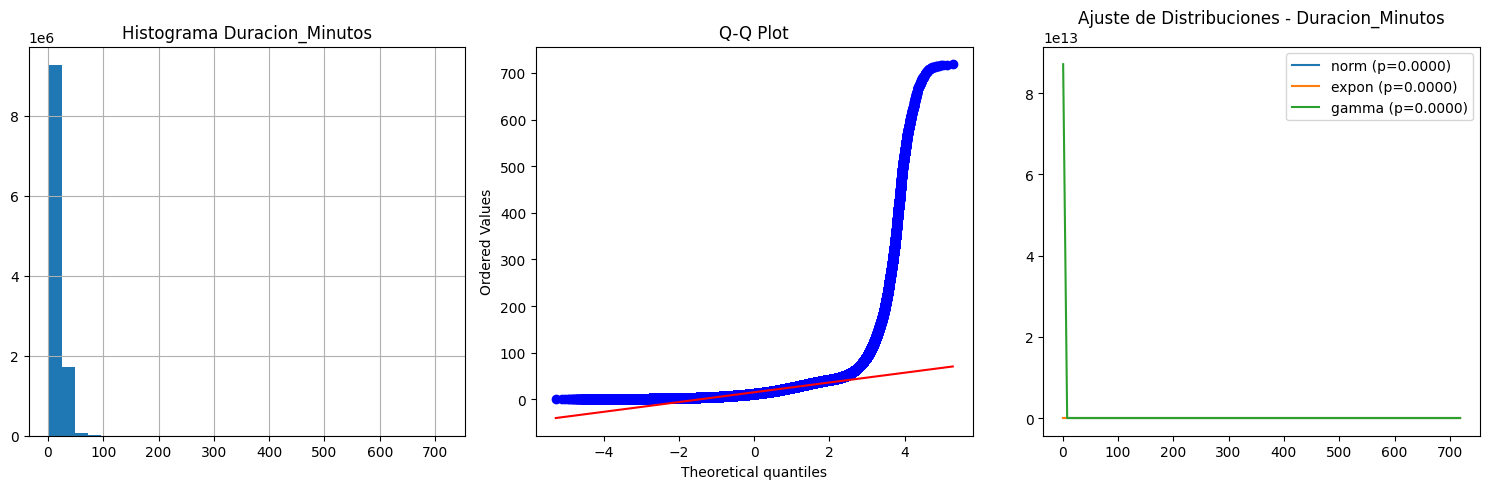


Resultados de Ajuste de Distribuciones:
Edad_Usuario: Best Distribution = gamma
Duracion_Minutos: Best Distribution = expon


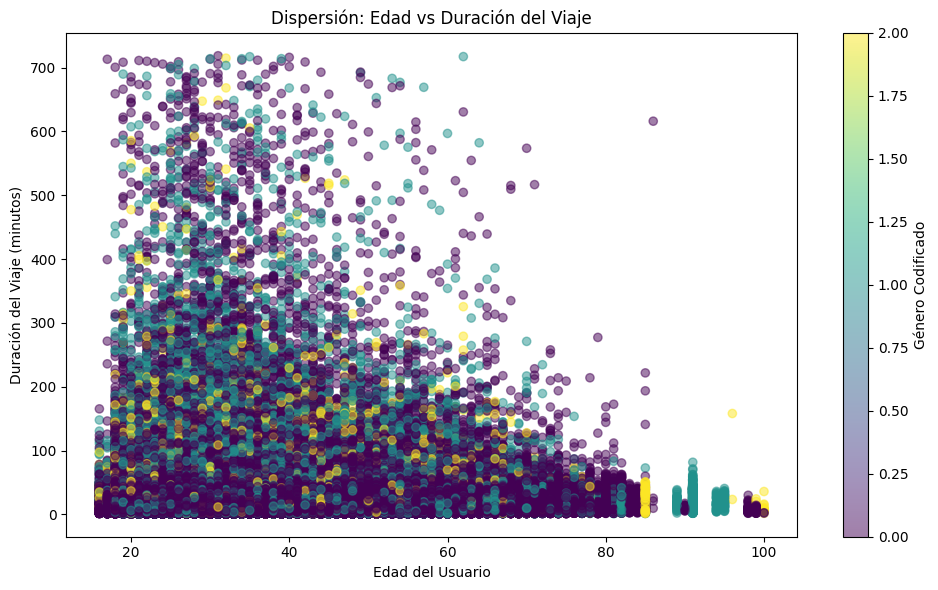

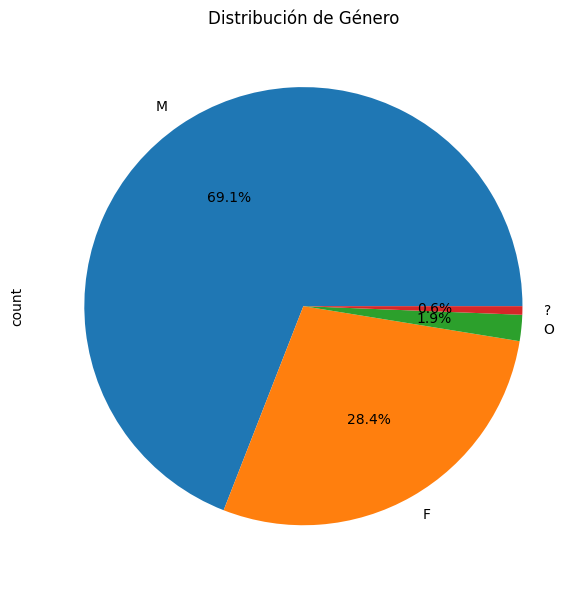

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Cargar datos previamente procesados
def load_processed_data(filepath='ecobici.csv'):
    df = pd.read_csv(filepath)
    return df

# Análisis de Correlación
def correlation_analysis(df):
    # Seleccionar variables numéricas
    numeric_cols = ['Edad_Usuario', 'Duracion_Minutos', 
                    'Ciclo_Estacion_Retiro', 'Ciclo_EstacionArribo', 
                    'Genero_Cod']
    
    # Crear matriz de correlación
    correlation_matrix = df[numeric_cols].corr()
    
    # Visualización de la matriz de correlación
    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
    plt.title('Matriz de Correlación - Variables Numéricas')
    plt.tight_layout()
    plt.show()
    plt.close()
    
    return correlation_matrix

# Análisis de Distribuciones
def distribution_analysis(df):
    # Distribuciones a analizar
    distributions = {
        'Edad_Usuario': [stats.norm, stats.expon, stats.gamma],
        'Duracion_Minutos': [stats.norm, stats.expon, stats.gamma]
    }
    
    results = {}
    
    for column, dist_list in distributions.items():
        data = df[column].dropna()
        best_dist = None
        best_kstest = float('inf')
        
        plt.figure(figsize=(15, 5))
        
        # Histograma original
        plt.subplot(131)
        data.hist(bins=30)
        plt.title(f'Histograma {column}')
        
        # Q-Q Plot y pruebas de bondad de ajuste
        plt.subplot(132)
        stats.probplot(data, dist=stats.norm, plot=plt)
        plt.title('Q-Q Plot')
        
        # Comparación de distribuciones
        plt.subplot(133)
        for dist in dist_list:
            params = dist.fit(data)
            # Test de Kolmogorov-Smirnov
            kstest_result = stats.kstest(data, dist.name, params)
            
            if kstest_result.statistic < best_kstest:
                best_dist = dist
                best_kstest = kstest_result.statistic
            
            # Graficar distribución ajustada
            x = np.linspace(data.min(), data.max(), 100)
            pdf = dist.pdf(x, *params[:-2], loc=params[-2], scale=params[-1])
            plt.plot(x, pdf, label=f'{dist.name} (p={kstest_result.pvalue:.4f})')
        
        plt.title(f'Ajuste de Distribuciones - {column}')
        plt.legend()
        plt.tight_layout()
        plt.show()
        plt.close()
        
        results[column] = {
            'best_distribution': best_dist.name,
            'ks_statistic': best_kstest
        }
    
    return results

# Visualizaciones Avanzadas
def advanced_visualizations(df):
    # Diagrama de dispersión: Edad vs Duración del Viaje
    plt.figure(figsize=(10, 6))
    plt.scatter(df['Edad_Usuario'], df['Duracion_Minutos'], 
                c=df['Genero_Cod'], cmap='viridis', alpha=0.5)
    plt.colorbar(label='Género Codificado')
    plt.xlabel('Edad del Usuario')
    plt.ylabel('Duración del Viaje (minutos)')
    plt.title('Dispersión: Edad vs Duración del Viaje')
    plt.tight_layout()
    plt.show()
    plt.close()
    
    # Distribución de Género
    plt.figure(figsize=(8, 6))
    df['Genero_Usuario'].value_counts().plot(kind='pie', autopct='%1.1f%%')
    plt.title('Distribución de Género')
    plt.tight_layout()
    plt.show()
    plt.close()

def main():
    # Cargar datos
    df = load_processed_data()
    
    # Análisis de Correlación
    correlation_matrix = correlation_analysis(df)
    print("Matriz de Correlación:\n", correlation_matrix)
    
    # Análisis de Distribuciones
    dist_results = distribution_analysis(df)
    print("\nResultados de Ajuste de Distribuciones:")
    for col, result in dist_results.items():
        print(f"{col}: Best Distribution = {result['best_distribution']}")
    
    # Visualizaciones Avanzadas
    advanced_visualizations(df)
    

if __name__ == "__main__":
    main()
